In [1]:
from matplotlib.dates import DateFormatter
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
import sqlite3

In [3]:
conn = sqlite3.connect('leetcode_data.db')

In [4]:
month = '2025-11-01'

In [5]:
rat_query = f"""
SELECT * FROM ranking WHERE date(dt, 'start of month')=='{month}'
"""

In [6]:
rating_df = pd.read_sql_query(rat_query, conn)

In [7]:
rating_df.head()

,dt,user_rank
0,2025-11-01 00:00:00,320628
1,2025-11-02 00:00:00,320628
2,2025-11-03 00:00:00,320628
3,2025-11-04 00:00:00,306004
4,2025-11-05 00:00:00,304703


In [8]:
pr_query = f"""
SELECT
dt,
COUNT(*) num_problems
FROM problems p
WHERE date(dt, 'start of month')=='{month}'
GROUP BY 1
ORDER BY 1
"""

In [9]:
problems_df  = pd.read_sql_query(pr_query, conn)

In [11]:
rating_df['dt'] = pd.to_datetime(rating_df['dt'])
problems_df['dt'] = pd.to_datetime(problems_df['dt'])
df = rating_df.merge(
    problems_df,
    how='left',
    on='dt'
)

In [12]:
df.head(20)

,dt,user_rank,num_problems
0,2025-11-01,320628,1
1,2025-11-02,320628,1
2,2025-11-03,320628,5
3,2025-11-04,306004,1
4,2025-11-05,304703,2
5,2025-11-06,304889,2
6,2025-11-07,299562,2
7,2025-11-08,297037,3
8,2025-11-09,293264,4
9,2025-11-10,289687,2


In [13]:
df['rate_lag'] = df['user_rank'].shift(1)
df['problem_lag'] = df['num_problems'].cumsum()

df['rate_diff'] = df['rate_lag'] - df['user_rank']
df['rate_diff2'] = df['rate_diff'].cumsum()

In [14]:
df.iloc[0, 1] - df.iloc[-1, 1]

np.int64(88009)

In [16]:
filename = 'my_file.png'
folder = 'img'
savepath = os.path.join(
    os.getcwd(),
    folder,
    filename
)

In [18]:
savepath

'/home/bakunobu/projects/pet/img/my_file.png'

In [24]:
def plot_progress(
                df,
                filename:str,
                folder:str='img'
                ):
        df = df.sort_values('dt')

        df['rate_lag'] = df['user_rank'].shift(1)
        df['problem_lag'] = df['num_problems'].cumsum()
        df['rate_diff'] = df['rate_lag'] - df['user_rank']
        df['rate_diff2'] = df['rate_diff'].cumsum()

        problems_solved = df.agg(
                num_problems=('num_problems', 'sum')
                ).values[0]
        
        pos_gainded = int(df.iloc[0, 1] - df.iloc[-1, 1])

        savepath = os.path.join(
                os.getcwd(),
                folder,
                filename
                )    

        # --- 2. FIGURE & LAYOUT SETUP ---
        # Set style
        plt.style.use('seaborn-v0_8')
        sns.set_palette("deep")

        # Create the main figure and the grid
        fig = plt.figure(figsize=(12, 10)) # Increased height to accommodate rows
        gs = fig.add_gridspec(2, 2)

        # --- 3. TOP PLOT (Incorporating Your Code) ---
        # Create the axis for the top row, spanning all columns
        ax1 = fig.add_subplot(gs[0, :])

        # [Your Code Adapted]: Primary Y-Axis (Left)
        sns.lineplot(x='dt', y='rate_diff2', data=df, ax=ax1, color='#007acc', linewidth=2.5, label='Rating')
        ax1.set_ylabel('Positions Overtaken', fontsize=12, color='#007acc', weight='bold')
        ax1.tick_params(axis='y', labelcolor='#007acc', length=6, width=1.2)
        ax1.set_xlabel('Date', fontsize=12, weight='bold')

        # [Your Code Adapted]: Customize x-axis date formatting
        date_form = DateFormatter("%d %b")
        ax1.xaxis.set_major_formatter(date_form)
        for label in ax1.get_xticklabels():
                label.set_rotation(30)

        # [Your Code Adapted]: Secondary Y-Axis (Right)
        ax2 = ax1.twinx()
        sns.lineplot(x='dt', y='problem_lag', data=df, ax=ax2, color='#d62728', linewidth=2.5, label='Problems Solved')
        ax2.set_ylabel('Problems Solved', fontsize=12, color='#d62728', weight='bold')
        ax2.tick_params(axis='y', labelcolor='#d62728', length=6, width=1.2)

        # [Your Code Adapted]: Title & Legend
        ax1.set_title('My LeetCode Progress (November 2025)', fontsize=16, weight='bold', color='darkslategray', pad=20)

        # Remove the automatic seaborn legend so we can use your custom one
        if ax1.get_legend(): ax1.get_legend().remove()
        if ax2.get_legend(): ax2.get_legend().remove()

        legend_elements = [
        Line2D([0], [0], color='#007acc', lw=2.5, label='Positions Taken'),
        Line2D([0], [0], color='#d62728', lw=2.5, label='Problems Solved')
        ]

        # Position legend
        legend = ax1.legend(
                handles=legend_elements, 
                loc='upper left',
                ncol=2,
                fontsize=11,
                frameon=True,
                fancybox=True,
                shadow=False,
                facecolor='white',
                edgecolor='gray'
                )
        legend.set_zorder(20)
        legend.get_frame().set_linewidth(1.2)

        # [Your Code Adapted]: Grid styling
        ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)
        ax1.grid(True, which='major', axis='y', linestyle='-', alpha=0.3)
        ax1.set_axisbelow(True) # Keep grid behind plot elements

        # --- 4. BOTTOM PLOTS (Side-by-Side) ---

        # Bottom Left Plot
        ax3 = fig.add_subplot(gs[1, 0])
        # Define the text and the arrow properties
        arrow_style = dict(
                arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
                fc="#d62728",  # Fill color
                ec="#d62728",  # Edge color
                linewidth=0 
        )

        ax3.annotate(
                text=f'+{problems_solved} PROBLEMS SOLD',
                xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
                xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
                xycoords='axes fraction', 
                textcoords='axes fraction',
                fontsize=24,
                fontweight='bold',
                ha='center',          # Horizontal alignment of the text
                va='center',          # Vertical alignment of the text
                arrowprops=arrow_style
                )

        # 3. Clean up the plot
        ax3.set_xticks([]) # Remove x-axis ticks
        ax3.set_yticks([]) # Remove y-axis ticks
        ax3.spines['top'].set_visible(False)    # Remove the top border
        ax3.spines['right'].set_visible(False) # Remove the right border
        ax3.spines['bottom'].set_visible(False) # Remove the bottom border
        ax3.spines['left'].set_visible(False)   # Remove the left border


        # Bottom Right Plot
        ax4 = fig.add_subplot(gs[1, 1])
        arrow_style = dict(
                arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
                fc="#007acc",  # Fill color
                ec="#007acc",  # Edge color
                linewidth=0
                )
        ax4.annotate(
                text=f'+{pos_gainded} POS GAINED',
                xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
                xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
                xycoords='axes fraction', 
                textcoords='axes fraction',
                fontsize=24,
                fontweight='bold',
                ha='center',          # Horizontal alignment of the text
                va='center',          # Vertical alignment of the text
                arrowprops=arrow_style
                )

        # 3. Clean up the plot
        ax4.set_xticks([]) # Remove x-axis ticks
        ax4.set_yticks([]) # Remove y-axis ticks
        ax4.spines['top'].set_visible(False)    # Remove the top border
        ax4.spines['right'].set_visible(False) # Remove the right border
        ax4.spines['bottom'].set_visible(False) # Remove the bottom border
        ax4.spines['left'].set_visible(False)   # Remove the left border

        plt.tight_layout()
        plt.subplots_adjust(top=0.92, hspace=0.4) # Add spacing between top and bottom rows
        plt.savefig(savepath)
        plt.show()

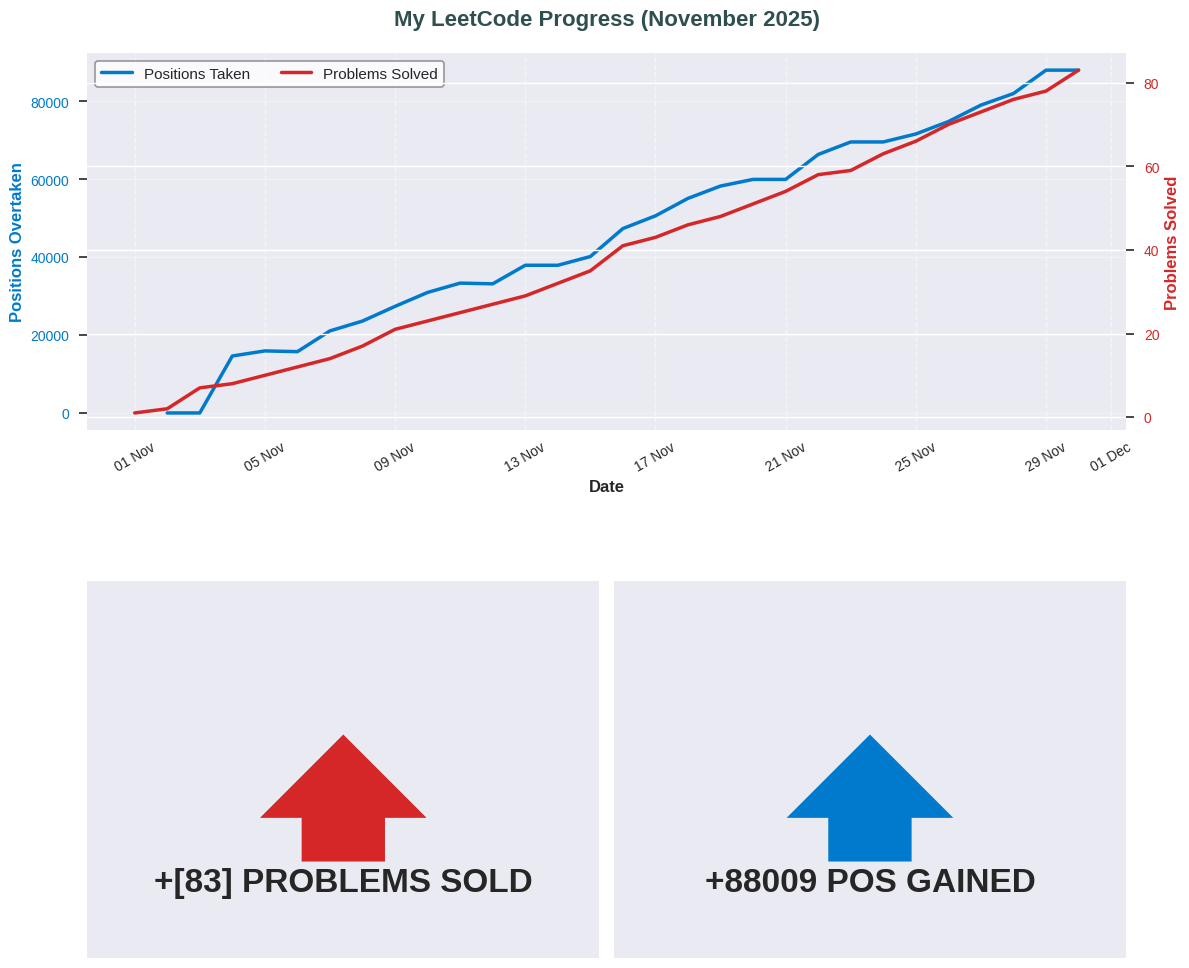

In [25]:
plot_progress(df, 'test_nov.png')

In [ ]:
def collect_data(
        month,
        conn,
        rat_tamplate:str="""SELECT * FROM ranking WHERE date(dt, 'start of month')=='{}'""",
        pr_template:str="""
        SELECT
        dt,
        COUNT(*) num_problems
        FROM problems p
        WHERE date(dt, 'start of month')=='{}'
        GROUP BY 1
        ORDER BY 1
        """
        ) -> pd.DataFrame:
    rat_query = rat_tamplate.format(month)
    pr_query = pr_template.format(month)
    
    rating_df = pd.read_sql_query(rat_query, conn)
    problems_df  = pd.read_sql_query(pr_query, conn)

    
    rating_df['dt'] = pd.to_datetime(rating_df['dt'])
    problems_df['dt'] = pd.to_datetime(problems_df['dt'])
    df = rating_df.merge(
        problems_df,
        how='left',
        on='dt'
        )
    
    return df
